In [3]:
from pycromanager import Core

In [4]:
core = Core()

In [5]:
r = core.get_roi()
print(r.width, r.height, r.x, r.y)
core.set_roi(100,100,20,20)
r = core.get_roi()
print(r.width, r.height, r.x, r.y)

20 20 100 100
20 20 100 100


In [6]:
def obj_2_list(name):
    """Convert Java object to Python list."""
    return [name.get(i) for i in range(name.size())]

In [7]:
obj_2_list(core.get_device_property_names("OSc-LSM"))

['Binning',
 'Clock',
 'Detector-0',
 'Detector-1',
 'Detector-2',
 'Detector-3',
 'Dev1-Acq Buffer Size (lines)',
 'Dev1-EnableChannel0',
 'Dev1-EnableChannel1',
 'Dev1-EnableChannel2',
 'Dev1-EnableChannel3',
 'Dev1-EnableChannel4',
 'Dev1-EnableChannel5',
 'Dev1-EnableChannel6',
 'Dev1-EnableChannel7',
 'Dev1-Fermat Spiral Min Radius (pixels)',
 'Dev1-Fermat Spiral Scan',
 'Dev1-Fermat Spiral Turn Duration (ms)',
 'Dev1-Fermat Spiral Turn Spacing (pixels)',
 'Dev1-Fermat Spiral X Center Offset (pixels)',
 'Dev1-Input Voltage Range',
 'Dev1-Line Delay (pixels)',
 'Dev1-Parking Position X (pixels)',
 'Dev1-Parking Position Y (pixels)',
 'Dev1-TransformA',
 'Dev1-TransformB',
 'Dev1-TransformC',
 'Dev1-TransformD',
 'Dev1-TransformOffsetXVolts',
 'Dev1-TransformOffsetYVolts',
 'Exposure',
 'LSM-EnableDetector-0-Dev1',
 'LSM-PixelRateHz',
 'LSM-Resolution',
 'LSM-ZoomFactor',
 'Scanner',
 'TransposeCorrection',
 'TransposeMirrorX',
 'TransposeMirrorY',
 'TransposeXY']

In [8]:
core.get_property("OSc-LSM","Dev1-Fermat Spiral Scan")

'Yes'

In [9]:
core.set_property("OSc-LSM","Dev1-Fermat Spiral Scan","Yes")
core.get_property("OSc-LSM","Dev1-Fermat Spiral Scan")

'Yes'

In [10]:
import time

In [11]:
from pycromanager import Studio
studio = Studio()

In [12]:
L = studio.live()

In [20]:
L.is_live_mode_on(), core.is_sequence_running()

(False, True)

In [25]:
print("Initial:", studio.live().is_live_mode_on(), core.is_sequence_running())

if core.is_sequence_running(): core.stop_sequence_acquisition()

core.start_continuous_sequence_acquisition(0)
# studio.live().set_live_mode_on(True)

print("After start:", studio.live().is_live_mode_on(), core.is_sequence_running())

for i in range(4):
    print(f"[{i+1}/4]:", studio.live().is_live_mode_on(), core.is_sequence_running())
    time.sleep(1)

core.stop_sequence_acquisition()

print("Final:", studio.live().is_live_mode_on(), core.is_sequence_running())

Initial: False False
After start: False True
[1/4]: False True
[2/4]: False True
[3/4]: False True
[4/4]: False True
Final: False False


In [30]:
#!uv pip list

In [ ]:
## editable install fails

In [33]:
!uv pip show pybhspc

Name: pybhspc
Version: 0.1.1.dev0
Location: C:\Users\lociuser\code\jenu\navigator\.venv\Lib\site-packages
Editable project location: C:\Users\lociuser\code\jenu\navigator\pybhspc
Requires:
Required-by:


In [ ]:
## whl install is okay

In [1]:
!uv pip show pybhspc

Name: pybhspc
Version: 0.1.1.dev0
Location: C:\Users\lociuser\code\jenu\navigator\.venv\Lib\site-packages
Requires:
Required-by:


In [2]:
import bh_spc
from bh_spc import spcm

In [26]:
import pprint
from collections import OrderedDict

In [27]:
spcm.init(r'C:\Program Files\Micro-Manager-2.0\spcm.ini')

In [31]:
mod_no = 0 # SPC 180NX
spcm.get_init_status(mod_no)

<InitStatus.OK: 0>

In [32]:
params = spcm.get_parameters(mod_no)
params_ = OrderedDict(params)

for k in params_:
    print(f'{k:<20} : {params_[k]:.3f}')

cfd_limit_low        : -29.412
cfd_limit_high       : 80.000
cfd_zc_level         : 12.850
cfd_holdoff          : 5.000
sync_zc_level        : -45.354
sync_freq_div        : 1.000
sync_holdoff         : 4.000
sync_threshold       : -9.804
tac_range            : 50.034
tac_gain             : 4.000
tac_offset           : 3.137
tac_limit_low        : 0.000
tac_limit_high       : 100.000
adc_resolution       : 12.000
ext_latch_delay      : 0.000
collect_time         : 10.000
display_time         : 1.000
repeat_time          : 10.000
stop_on_time         : 1.000
stop_on_ovfl         : 0.000
dither_range         : 128.000
count_incr           : 1.000
mem_bank             : 0.000
dead_time_comp       : 0.000
scan_control         : 0.000
routing_mode         : 0.000
tac_enable_hold      : 0.000
mode                 : 5.000
scan_size_x          : 1.000
scan_size_y          : 1.000
scan_rout_x          : 1.000
scan_rout_y          : 1.000
scan_polarity        : 7.000
scan_flyback         : 65537

In [36]:
def get_microtimes_MT(duration = 0.1, buf_size = 32768, mod_no=0):

    spcm.start_measurement(mod_no)
    start_time = time.monotonic()

    data = []  # Collect arrays of data into a list.
    while True:
        elapsed = time.monotonic() - start_time
        if elapsed >= duration:
            spcm.stop_measurement(mod_no)
            break
        buf = spcm.read_fifo_to_array(mod_no, buf_size)
        if len(buf):
            data.append(buf)
        if len(buf) < buf_size:  # We've read all there is to read.
            time.sleep(0.001)

    # Make sure to read the data that arrived after stopping (if you need it).
    while True:
        buf = spcm.read_fifo_to_array(mod_no, buf_size)
        if not len(buf):
            break
        data.append(buf)

    records = np.concatenate(data).view(np.uint32)
    len(records)

    had_gap = np.any(np.bitwise_and(records, 1 << 29))
    print("There was {} gap".format("a" if had_gap else "no"))

    photons = np.extract(np.bitwise_and(records, 0b1001 << 28) == 0, records)
    len(photons)

    max_12bit = (1 << 12) - 1  # 4095
    microtimes = np.bitwise_and(np.right_shift(photons, 16), max_12bit)

    # Reverse the microtimes by subtracting from the max value, because the raw
    # microtime is measured from photon to SYNC, not SYNC to photon.
    microtimes = max_12bit - microtimes
    
    return microtimes,photons


In [37]:
params.collect_time = 2 # sec
spcm.set_parameters(0, params)

In [38]:
duration = spcm.get_parameter(mod_no,spcm.ParID.COLLECT_TIME)  # s
buf_size = 2**15  # Max number of 16-bit words in a single read.
duration, buf_size

(2.0, 32768)

In [39]:
import datetime
def print_time():
    print(datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

In [45]:
!uv add matplotlib

Resolved 129 packages in 674ms
Prepared 4 packages in 1.18s
Uninstalled 1 package in 5ms
Installed 8 packages in 432ms
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.62.1
 + kiwisolver==1.5.0
 + matplotlib==3.10.8
 ~ navigator==0.1.0 (from file:///C:/Users/lociuser/code/jenu/navigator)
 + pillow==12.2.0
 + pyparsing==3.3.2


In [46]:
!uv pip show navigator

Name: navigator
Version: 0.1.0
Location: C:\Users\lociuser\code\jenu\navigator\.venv\Lib\site-packages
Editable project location: C:\Users\lociuser\code\jenu\navigator
Requires: imgui-bundle, ipython, jupyterlab, matplotlib, pycromanager, pyopengl
Required-by:


In [48]:
import numpy as np
from matplotlib import pyplot as plt

2026-04-09 11:32:46
There was no gap
6 6
30
2026-04-09 11:32:48
There was no gap
1 1
32
2026-04-09 11:32:50
There was no gap
2 2
0


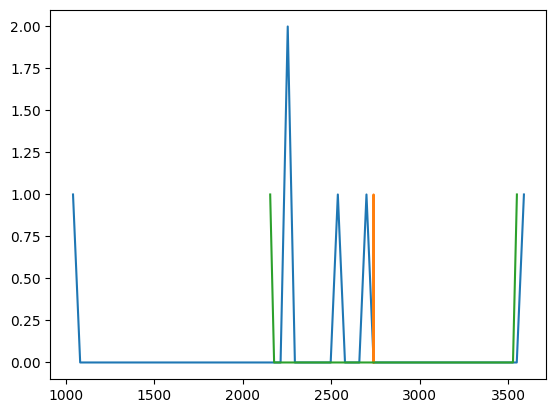

In [61]:

for k in range(3):
    print_time()
    mt,ph = get_microtimes_MT(duration,buf_size)
    print(len(mt),len(ph))
    x,h = np.histogram(mt,64)
    plt.plot(h[:-1],x)
    print(np.argmax(x))

In [51]:
duration

2.0

In [52]:
duration_s = 10

In [54]:
from pathlib import Path


## this spc file-saving below doesnt work! 



In [62]:
spcm.set_parameter(mod_no, spcm.ParID.MODE, 1)  # FIFO mode for most modern boards

filename = Path(datetime.datetime.now().strftime("%Y%m%d_%H%M%S.spc"))

with filename.open("wb") as f:
    spcm.start_measurement(mod_no)
    start = time.monotonic()

    try:
        while time.monotonic() - start < duration_s:
            buf = spcm.read_fifo_to_array(mod_no, buf_size)
            if len(buf):
                buf.tofile(f)  # writes raw uint16 FIFO words
            if len(buf) < buf_size:
                time.sleep(0.001)
    finally:
        spcm.stop_measurement(mod_no)

        # drain anything that arrived just before/after stop
        while True:
            buf = spcm.read_fifo_to_array(mod_no, buf_size)
            if not len(buf):
                break
            buf.tofile(f)

print(f"Saved raw FIFO stream to {filename}")

Saved raw FIFO stream to 20260409_113304.spc


In [65]:
!dir *.spc

 Volume in drive C is OS
 Volume Serial Number is 461C-31DB

 Directory of C:\Users\lociuser\code\jenu\navigator

04/09/2026  11:21 AM             2,424 20260409_112129.spc
04/09/2026  11:27 AM                 4 20260409_112751.spc
04/09/2026  11:28 AM                 4 20260409_112833.spc
04/09/2026  11:33 AM                24 20260409_113304.spc
               4 File(s)          2,456 bytes
               0 Dir(s)  790,058,881,024 bytes free
